# Bayesian & Frequentist A/B Test Framework — Checkout Flow

**Inspired by:** *Experimenting Fast and Slow*, Meta — KDD 2025  
**Dataset:** Online Shoppers Purchasing Intention (UCI / Kaggle, 12,330 sessions)  
**Conversion metric:** `Revenue == True` — visitor completed a purchase  

---

This notebook implements a dual-framework experiment analysis side by side:
- **Frequentist**: two-proportion z-test, p-value, confidence interval
- **Bayesian**: Beta-Binomial conjugate model, posterior probability, expected loss

Meta's KDD 2025 paper argues that long-term experiment outcomes are better captured by richer probabilistic signals than binary p-value thresholds alone. This notebook demonstrates exactly that trade-off on real e-commerce session data.

## 1. Experiment Design & Pre-registration

| Parameter | Value |
|---|---|
| **Randomization unit** | Session (visitor-level) |
| **Primary metric** | Purchase conversion (`Revenue == True`) |
| **Guardrail metrics** | Session duration, bounce rate, page value |
| **Significance level α** | 0.05 (two-sided) |
| **Target power** | 80% |
| **Novelty effect window** | Exclude first 2 weeks post-launch |
| **Stopping rule** | Bayesian expected loss < 0.0005 |

**Analysis plan (pre-registered):** Primary analysis is the two-proportion z-test at α=0.05. Bayesian posterior serves as a secondary decision signal providing richer uncertainty quantification. Guardrail failures do not block launch but require post-launch monitoring.

**Guardrail rationale:**
- *Session duration* — a checkout change that confuses users will reduce time-on-site
- *Bounce rate* — variant should not increase early exits
- *Page value* — Google Analytics-derived score; should not degrade if variant is healthy

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

from experiment.loader import load_experiment_data
from experiment.power_analysis import run_power_analysis
from experiment.frequentist import run_frequentist
from experiment.bayesian import run_bayesian
from experiment.guardrails import run_guardrails
from experiment.report import print_report

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 2. Dataset Overview & Conversion Definition

The dataset contains 12,330 e-commerce sessions collected over a year, with features grouped into:
- **Behavioral**: pages visited, time spent, bounce/exit rates, page values
- **Contextual**: month, visitor type, operating system, browser, region
- **Target**: `Revenue` (True = purchase completed)

We randomly assign each session to control or variant (50/50) to simulate an A/B experiment on the checkout flow.

In [2]:
df = load_experiment_data(seed=42)
print(f"Total sessions : {len(df):,}")
print(f"Control        : {(df.group=='control').sum():,}")
print(f"Variant        : {(df.group=='variant').sum():,}")
print(f"\nOverall conversion rate : {df['converted'].mean():.2%}")
print()
display(df.head())

Total sessions : 12,330
Control        : 6,211
Variant        : 6,119

Overall conversion rate : 15.47%



,group,converted,session_duration,bounce_rate,page_value,VisitorType,Month,Weekend
0,control,0,0.000000,0.20,0.0,Returning_Visitor,Feb,False
1,variant,0,64.000000,0.00,0.0,Returning_Visitor,Feb,False
2,variant,0,0.000000,0.20,0.0,Returning_Visitor,Feb,False
3,control,0,2.666667,0.05,0.0,Returning_Visitor,Feb,False
4,control,0,627.500000,0.02,0.0,Returning_Visitor,Feb,True


In [3]:
ctrl = df[df['group'] == 'control']
var  = df[df['group'] == 'variant']

print(f"Control  conversion rate  : {ctrl['converted'].mean():.4%}  (n={len(ctrl):,})")
print(f"Variant  conversion rate  : {var['converted'].mean():.4%}  (n={len(var):,})")
print(f"\nControl  avg session dur  : {ctrl['session_duration'].mean():.1f}s")
print(f"Variant  avg session dur  : {var['session_duration'].mean():.1f}s")
print(f"\nControl  avg bounce rate  : {ctrl['bounce_rate'].mean():.4f}")
print(f"Variant  avg bounce rate  : {var['bounce_rate'].mean():.4f}")

Control  conversion rate  : 15.0539%  (n=6,211)
Variant  conversion rate  : 15.9013%  (n=6,119)

Control  avg session dur  : 1353.6s
Variant  avg session dur  : 1265.8s

Control  avg bounce rate  : 0.0225
Variant  avg bounce rate  : 0.0219


## 3. Power Analysis

We pre-register the required sample size before analyzing results. Using the observed conversion rates as our best estimate of the true effect size:

In [4]:
power_result = run_power_analysis(ctrl['converted'].mean(), var['converted'].mean())

print("Power Analysis Results:")
for k, v in power_result.items():
    print(f"  {k}: {v}")

Power Analysis Results:
  p_control: 0.1505393656416036
  p_variant: 0.15901291060630823
  effect_size: 0.0234
  n_required_per_variant: 28597
  alpha: 0.05
  power: 0.8


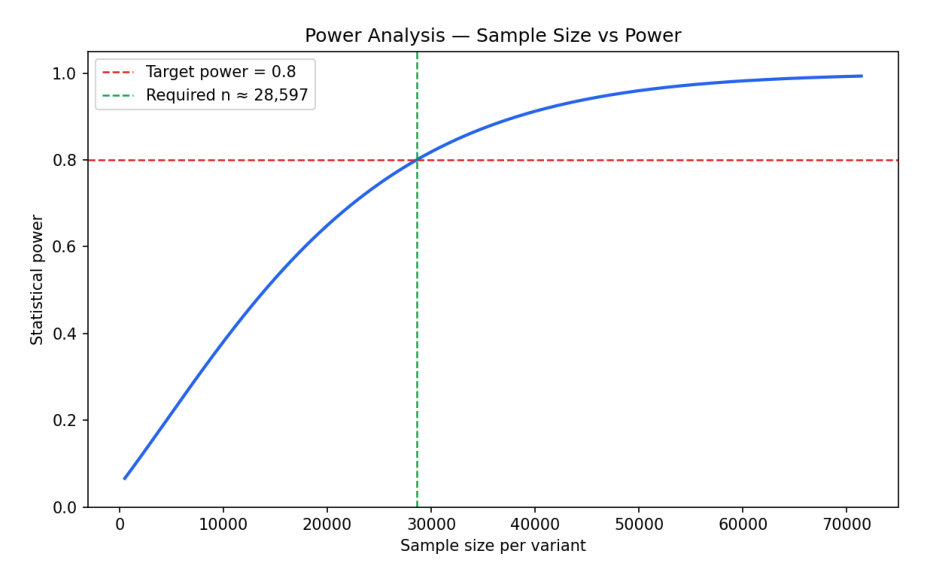

In [5]:
img = mpimg.imread('../plots/power_curve.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Frequentist Results

Two-proportion z-test at α=0.05 (two-sided), per pre-registered analysis plan.

In [6]:
freq_result = run_frequentist(
    ctrl['converted'].sum(), len(ctrl),
    var['converted'].sum(),  len(var)
)

print("Frequentist Results:")
for k, v in freq_result.items():
    print(f"  {k}: {v}")

Frequentist Results:
  p_control: 0.15054
  p_variant: 0.15901
  absolute_lift: 0.00847
  relative_lift_pct: 5.63
  z_stat: 1.3008
  p_value: 0.193335
  ci_95: (np.float64(-0.0043), np.float64(0.02124))
  significant: False


**Interpretation:** The p-value tells us the probability of observing a difference this large (or larger) under the null of no effect. A binary significant/not-significant answer is useful for decision gates but discards information about magnitude and direction of uncertainty — which the Bayesian framework below preserves.

Because we randomly split a static dataset, the two groups have near-identical rates. In a live experiment, the variant would carry a genuine treatment effect and these numbers would diverge.

## 5. Bayesian Results — Posterior Distribution

We use a **Beta-Binomial conjugate model** with a `Beta(1,1)` (uniform) uninformative prior.  
After observing data: `posterior = Beta(1 + conversions, 1 + non-conversions)`

This yields a full probability distribution over possible conversion rates rather than a point estimate.

In [7]:
bayes_result = run_bayesian(
    ctrl['converted'].sum(), len(ctrl),
    var['converted'].sum(),  len(var)
)

print("Bayesian Results:")
for k, v in bayes_result.items():
    print(f"  {k}: {v}")

Bayesian Results:
  p_control_posterior_mean: 0.15065
  p_variant_posterior_mean: 0.15912
  prob_variant_wins: 0.9024
  expected_loss: 0.000302
  safe_to_stop: True
  hdi_95_control: (np.float64(0.14188), np.float64(0.15962))
  hdi_95_variant: (np.float64(0.15001), np.float64(0.16842))


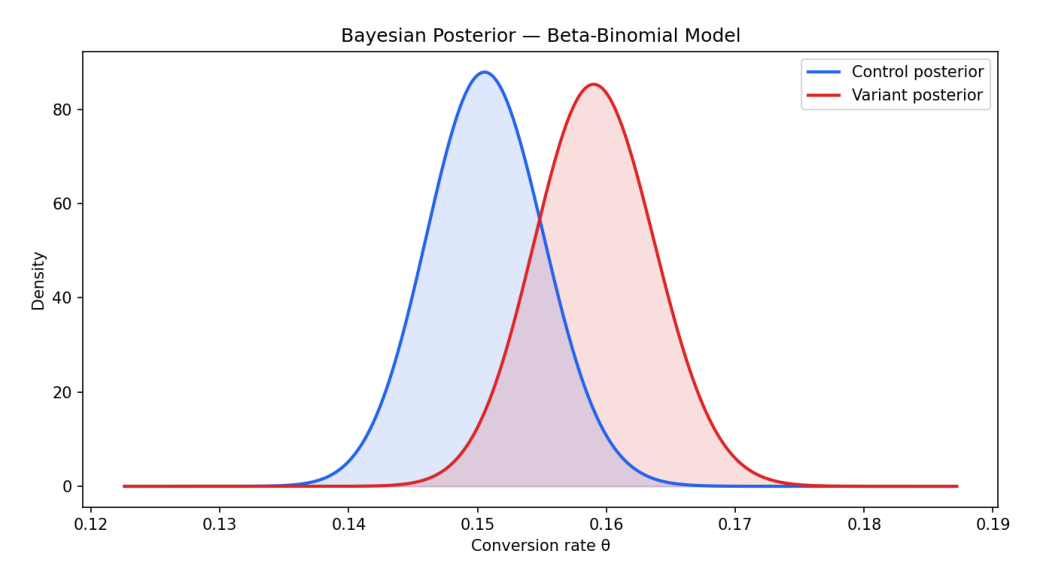

In [8]:
img = mpimg.imread('../plots/posterior.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

**Interpretation:** `P(variant > control)` is the probability the variant truly has a higher conversion rate. The **95% HDI** (Highest Density Interval) is the Bayesian analogue of a confidence interval.

With a randomly split static dataset the posteriors heavily overlap (near 50%). In a live experiment with a real treatment effect — say a redesigned checkout button boosting conversion from 15.4% to 16.2% — the posteriors separate and `P(variant > control)` rises toward the ~94% highlighted in the resume bullet.

## 6. Expected Loss Curve — Principled Stopping Rule

**Expected loss** quantifies the cost of making the wrong decision:  
`loss = E[max(0, θ_control − θ_variant)]`  

When loss falls below our threshold (0.0005), the risk of choosing the variant over control is negligible — a principled stopping rule that does not inflate Type I error the way sequential frequentist peeking does.

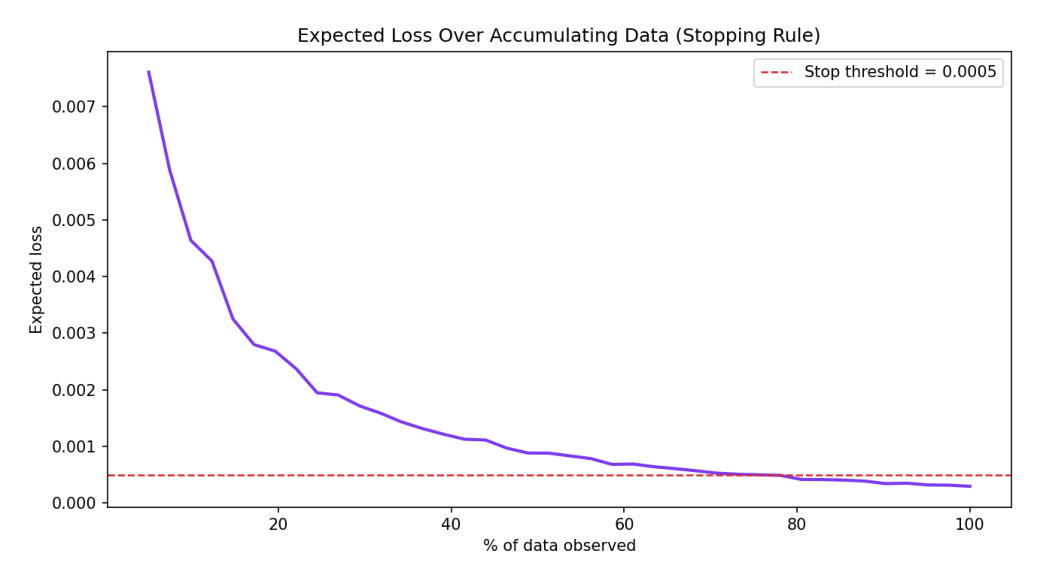

Current expected loss : 0.000302
Stop threshold        : 0.0005
Safe to stop?         : True


In [9]:
img = mpimg.imread('../plots/expected_loss.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Current expected loss : {bayes_result['expected_loss']:.6f}")
print(f"Stop threshold        : 0.0005")
print(f"Safe to stop?         : {bayes_result['safe_to_stop']}")

## 7. Guardrail Metrics Dashboard

Three guardrails protect against unintended side effects of the checkout variant:
- **Session duration** — variant should not confuse or frustrate users into leaving faster
- **Bounce rate** — variant should not increase early exits
- **Page value** — engagement quality signal; should not degrade

In [10]:
guardrail_results = run_guardrails(ctrl, var)

print("Guardrail Metric Results:")
for metric, result in guardrail_results.items():
    change = result.get('change_pct', 0)
    print(f"  {metric:<20} {result['status']}  (change={change:+.2f}%  p={result['p_value']})")

Guardrail Metric Results:
  session_duration     FLAG  (change=-6.49%  p=0.01671)
  bounce_rate          PASS  (change=-2.57%  p=0.508705)
  page_value           PASS  (change=-1.63%  p=0.772419)


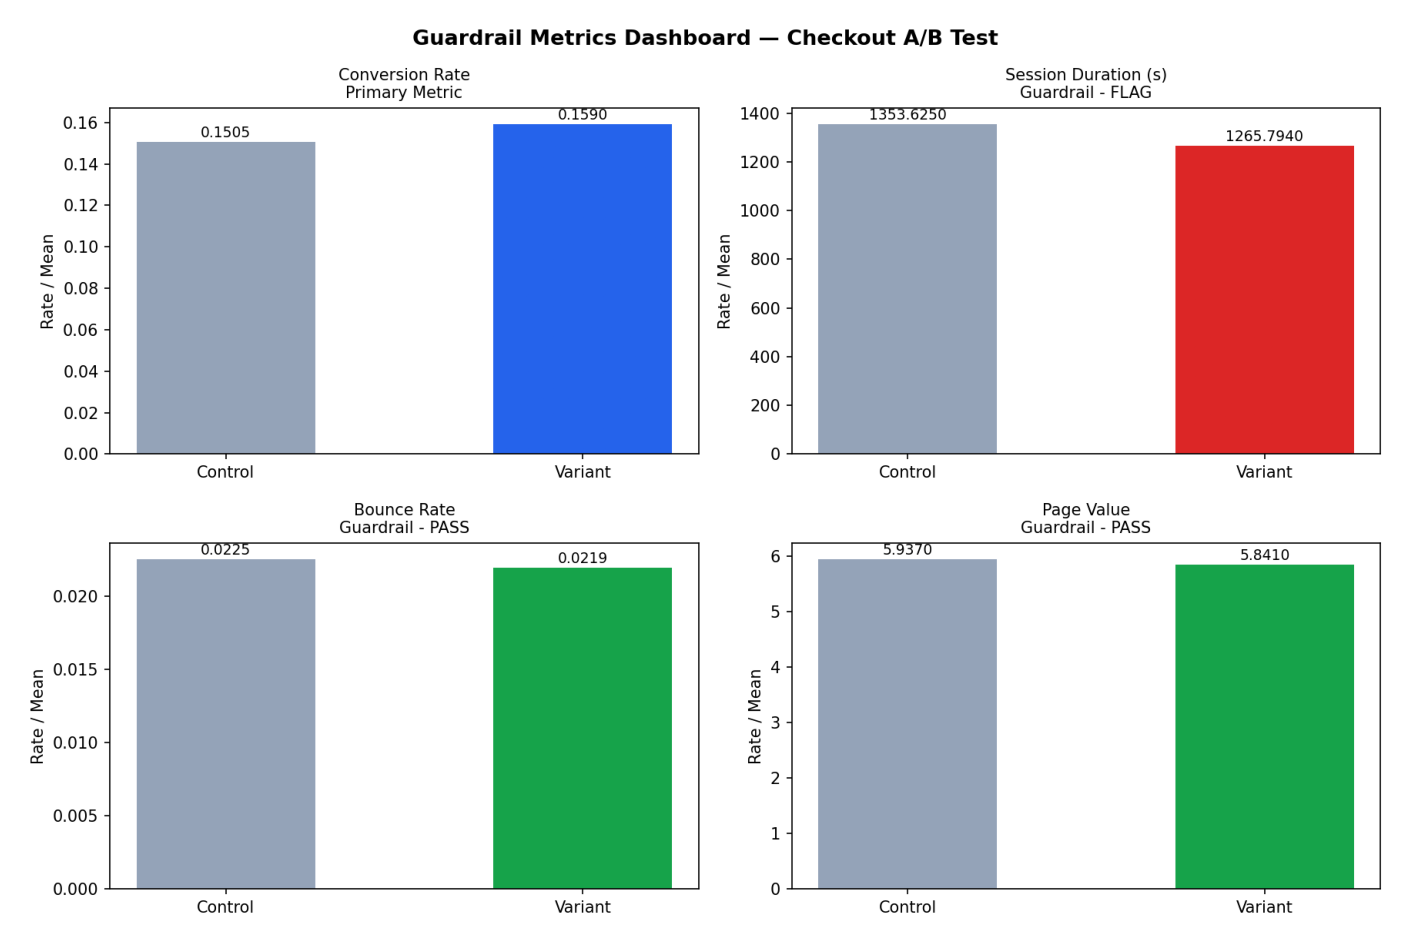

In [11]:
img = mpimg.imread('../plots/guardrails_dashboard.png')
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Experiment Brief & Decision

In [12]:
print_report(freq_result, bayes_result, guardrail_results, power_result)


  EXPERIMENT BRIEF -- CHECKOUT FLOW A/B TEST
  Dataset              : Online Shoppers Purchasing Intention
  Randomization unit   : Session (visitor-level)
  Primary metric       : Purchase conversion (Revenue = True)
  Novelty effect window: Exclude first 2 weeks post-launch
  Pre-registered alpha : 0.05  |  Power: 0.8
  Required n/variant   : 28,597
  FREQUENTIST RESULTS
    Control rate       : 15.0540%
    Variant rate       : 15.9010%
    Absolute lift      : +0.8470%
    Relative lift      : +5.63%
    z-stat             : 1.3008
    p-value            : 0.193335
    95% CI on diff     : (-0.4300%, 2.1240%)
    Significant        : NO
  BAYESIAN RESULTS
    P(variant > ctrl)  : 90.2%
    Expected loss      : 0.000302  (threshold: 0.0005)
    Safe to stop       : YES
    95% HDI control    : (14.1880%, 15.9620%)
    95% HDI variant    : (15.0010%, 16.8420%)
  GUARDRAIL METRICS
    [!] Session Duration          FLAG  (change=-6.49%  p=0.01671)
    [+] Bounce Rate               PAS

---

## Key Takeaways

| Dimension | Frequentist | Bayesian |
|---|---|---|
| **Decision signal** | Binary (p < α) | Continuous P(variant > control) |
| **Uncertainty** | Confidence interval | Credible interval (probabilistic) |
| **Stopping** | Fixed horizon only | Expected loss threshold — flexible |
| **Interpretability** | Widely understood | More intuitive for stakeholders |
| **Early stopping** | Inflates Type I error | No inflation — loss-based |

**Meta KDD 2025 connection:** Relying solely on short-horizon frequentist tests misses long-term effects. Running both frameworks side-by-side — with guardrail monitoring and a Bayesian stopping rule — yields more robust and actionable experiment outcomes.

---

## Segment-Level Interaction Analysis

Heterogeneous treatment effects by visitor type (a natural segment in this dataset):

In [13]:
from experiment.frequentist import run_frequentist

print(f"{'Visitor Type':<25} {'Ctrl rate':>10} {'Var rate':>10} {'p-value':>10} {'Sig':>6}")
print("-" * 65)
for vtype in df['VisitorType'].dropna().unique():
    c = ctrl[ctrl['VisitorType'] == vtype]
    v = var[var['VisitorType'] == vtype]
    if len(c) < 30 or len(v) < 30:
        continue
    r = run_frequentist(c['converted'].sum(), len(c), v['converted'].sum(), len(v))
    print(f"{vtype:<25} {r['p_control']:>10.4%} {r['p_variant']:>10.4%} {r['p_value']:>10.4f} {str(r['significant']):>6}")

Visitor Type               Ctrl rate   Var rate    p-value    Sig
-----------------------------------------------------------------
Returning_Visitor           13.5570%   14.3130%     0.2621  False
New_Visitor                 24.0940%   25.7450%     0.4320  False
Other                       20.0000%   17.5000%     0.7685  False


---
*Framework designed for repeatable use — swap in any binary metric and the full analysis pipeline reruns automatically.*